<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/deep_learning/Demo_Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiclass Image Classification with MLP (Fashion MNIST)

## Introduction

In binary classification we output a single probability $\hat{y} \in (0,1)$ using the **sigmoid** function. For $K > 2$ classes we need a generalisation: the **softmax** function, which outputs a probability vector $\hat{\mathbf{p}} \in \mathbb{R}^K$ with $\sum_k \hat{p}_k = 1$.

## The Softmax Function

$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

**Properties:**
- All outputs in $(0,1)$ and sum to 1 → valid probability distribution
- Amplifies the largest logit (relative to others) — "winner-take-more"
- Numerically stable implementation: subtract $\max(\mathbf{z})$ before exponentiating

## Categorical Cross-Entropy Loss

For a single example with true class $y \in \{1,\ldots,K\}$:

$$\mathcal{L} = -\log \hat{p}_y = -z_y + \log \sum_{j=1}^K e^{z_j}$$

The loss is minimised when $\hat{p}_y \to 1$. Note: `nn.NLLLoss` + `log_softmax` in the forward pass is mathematically identical to `nn.CrossEntropyLoss` with raw logits.

## Notation

| Symbol | Meaning |
|--------|---------|
| $K=10$ | Number of classes |
| $H=W=28$ | Image height/width (pixels) |
| $n = H \times W = 784$ | Flattened input size |
| $\mathbf{z} \in \mathbb{R}^K$ | Logit vector (pre-softmax) |
| $\hat{\mathbf{p}} \in \mathbb{R}^K$ | Predicted class probabilities |

## Roadmap

1. Load and explore **Fashion MNIST** (70K images, 10 classes)
2. Pre-process: normalise pixel values and create DataLoaders
3. Build a 2-layer **MLP** (784 → 128 → 10)
4. Train and evaluate
5. Visualise predictions

In [37]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

## Import the Fashion MNIST Dataset

[Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) contains 70,000 grayscale images (60K train / 10K test) of 10 clothing categories at 28×28 pixels — a more challenging drop-in replacement for digit MNIST.

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite" width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

We use 60,000 images for training and 10,000 for evaluation.

In [38]:
# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True)
# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False)

In [39]:
train_images = trainset.data.numpy()
train_labels = trainset.targets.numpy()

test_images = testset.data.numpy()
test_labels = testset.targets.numpy()

Images are NumPy arrays of shape (28, 28) with pixel values in [0, 255]. Labels are integers in {0, …, 9}:

<table>
  <tr><th>Label</th><th>Class</th><th>Label</th><th>Class</th></tr>
  <tr><td>0</td><td>T-shirt/top</td><td>5</td><td>Sandal</td></tr>
  <tr><td>1</td><td>Trouser</td><td>6</td><td>Shirt</td></tr>
  <tr><td>2</td><td>Pullover</td><td>7</td><td>Sneaker</td></tr>
  <tr><td>3</td><td>Dress</td><td>8</td><td>Bag</td></tr>
  <tr><td>4</td><td>Coat</td><td>9</td><td>Ankle boot</td></tr>
</table>

In [40]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Dataset Exploration

In [41]:
train_images.shape

(60000, 28, 28)

In [42]:
len(train_labels)

60000

Each label is an integer in {0, …, 9}:

In [43]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Test set dimensions:

In [44]:
test_images.shape

(10000, 28, 28)

In [45]:
len(test_labels)

10000

## Pre-processing

Pixel intensities are integers in [0, 255]. We **normalise** to [0.0, 1.0] by dividing by 255.

This ensures all inputs are on the same scale, which stabilises gradient magnitudes and speeds up convergence.

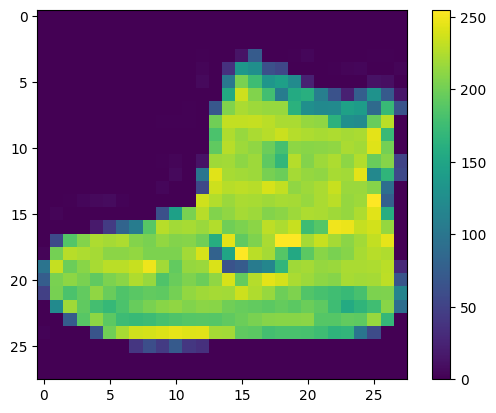

In [46]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

Rescale pixel values to [0, 1]:

In [47]:
train_images = train_images / 255.0
test_images = test_images / 255.0

Sample images from the training set:

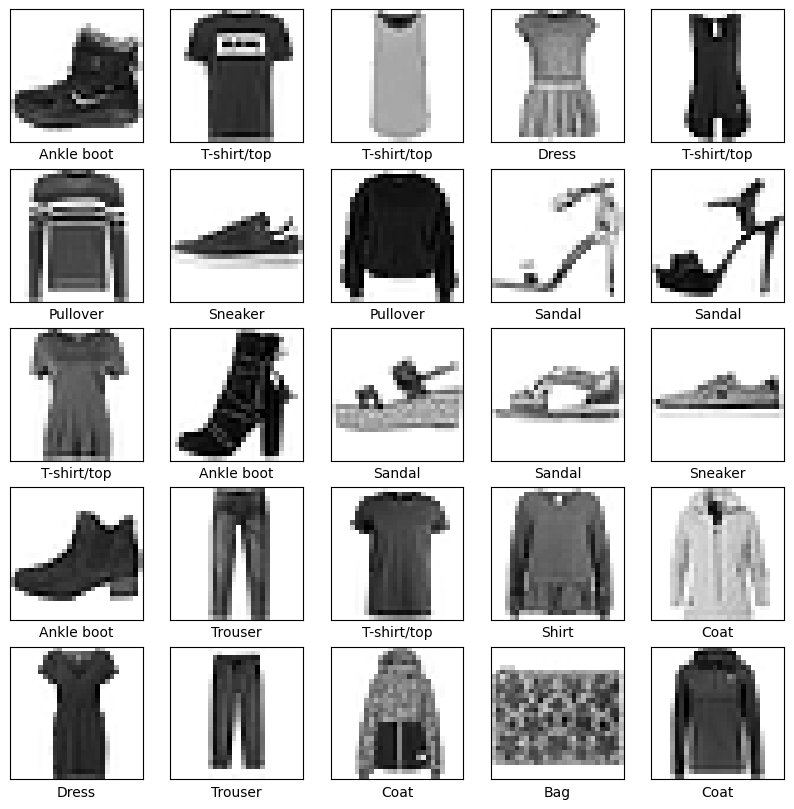

In [48]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

## Prepare DataLoaders

PyTorch `DataLoader` handles batching and shuffling. A batch size of 64 is standard for Fashion MNIST.

In [49]:
from torch.utils.data import DataLoader, TensorDataset

# Create TensorDatasets
train_dataset = torch.tensor(train_images, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.long)
test_dataset = torch.tensor(test_images, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(train_dataset, train_labels)
test_dataset = TensorDataset(test_dataset, test_labels)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Build the MLP Model

### Architecture

The MLP flattens each 28×28 image to a vector of 784 values, then passes it through two fully-connected layers:

$$\mathbf{x} \in \mathbb{R}^{784} \xrightarrow{W_1, b_1} \mathbf{h} \in \mathbb{R}^{128} \xrightarrow{\text{ReLU}} \mathbf{h}' \xrightarrow{W_2, b_2} \mathbf{z} \in \mathbb{R}^{10} \xrightarrow{\text{log-softmax}} \log \hat{\mathbf{p}}$$

Weight matrix sizes:
$$W_1 \in \mathbb{R}^{128 \times 784}, \quad W_2 \in \mathbb{R}^{10 \times 128}$$

**Note:** An MLP cannot exploit the spatial structure of images — it treats every pixel as an independent feature. CNNs address this limitation (see `Demo_CNN_Multiclass.ipynb`).

In [50]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = Net()

The `view(-1, 784)` flattens each 28×28 image to a 784-dimensional vector. The two `Linear` layers implement $\mathbf{z} = W\mathbf{x} + b$, and `F.log_softmax` provides numerically stable log-probabilities for use with `NLLLoss`.

**Total parameters:** $128 \times 784 + 128 + 10 \times 128 + 10 = 101{,}770$

In [51]:
from torchsummary import summary

summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]         100,480
            Linear-2                   [-1, 10]           1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.39
Estimated Total Size (MB): 0.39
----------------------------------------------------------------


## Define Loss, Optimizer, and Accuracy Metric

**Loss — `NLLLoss`:** expects log-probabilities from `log_softmax`. Together they implement categorical cross-entropy:
$$\mathcal{L} = -\frac{1}{m}\sum_{i=1}^m \log \hat{p}_{y_i}^{(i)}$$

**Optimizer — Adam:** adaptive learning rate optimiser (see MLP_pytorch notebook for details).

In [52]:
criterion = nn.NLLLoss() # loss = -1/N * sum(target_i * log(predicted_prob_i)) predefinido en pytorch.
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [53]:
def accuracy(output, target):
  _, predicted = torch.max(output.data, 1)
  correct = (predicted == target).sum().item()
  accuracy = correct / target.size(0)
  return accuracy

## Train the Model

The training loop:
1. Zero gradients: `optimizer.zero_grad()`
2. Forward pass: `output = model(images)`
3. Compute loss: `loss = criterion(output, labels)`
4. Backward pass: `loss.backward()`
5. Update weights: `optimizer.step()`

In [54]:
epochs = 3
for e in range(epochs):
  running_loss = 0
  running_accuracy = 0  # Initialize accuracy for the epoch
  for images, labels in train_loader:
    # Training pass
    optimizer.zero_grad()

    output = model(images)
    loss = criterion(output, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    running_accuracy += accuracy(output, labels)  # Accumulate accuracy

  # Calculate average loss and accuracy for the epoch
  epoch_loss = running_loss / len(train_loader)
  epoch_accuracy = running_accuracy / len(train_loader)

  print(f"Training loss of epoch {e}: {epoch_loss}, Accuracy: {epoch_accuracy}")

Training loss of epoch 0: 0.5095173210652271, Accuracy: 0.8157649253731343
Training loss of epoch 1: 0.4093785190633111, Accuracy: 0.8516457889125799
Training loss of epoch 2: 0.38337301678939667, Accuracy: 0.8616238006396588


## Evaluate on Test Set

In [55]:
def accuracy(output, target):
  _, predicted = torch.max(output.data, 1)
  correct = (predicted == target).sum().item()
  accuracy = correct / target.size(0)
  return accuracy

In [56]:
running_accuracy = 0  # Initialize accuracy for the epoch
for images, labels in test_loader:
  output = model(images)
  running_accuracy += accuracy(output, labels)  # Accumulate accuracy

test_accuracy = running_accuracy / len(test_loader)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.8451433121019108


The test accuracy is slightly lower than training accuracy — a mild case of **overfitting**. The model has partially memorised training patterns that don't fully generalise. See `Demo_CNN_Multiclass.ipynb` for techniques (augmentation, dropout) to mitigate this.

## Make Predictions

In [57]:
print(test_images.shape)

(10000, 28, 28)


In [58]:
with torch.no_grad():
  predictions = model(torch.tensor(test_images, dtype=torch.float32))

In [59]:
print(predictions.shape)

torch.Size([10000, 10])


In [60]:
predictions[0]

tensor([-15.3605, -23.8215, -27.1775, -21.4133, -22.4221,  -3.5929, -20.8128,
         -4.3339, -20.2750,  -0.0415])

In [61]:
predictions = torch.exp(predictions)

In [62]:
predictions[0]

tensor([2.1331e-07, 4.5129e-11, 1.5738e-12, 5.0155e-10, 1.8290e-10, 2.7518e-02,
        9.1436e-10, 1.3116e-02, 1.5655e-09, 9.5937e-01])

In [63]:
print(sum(predictions[0]))

tensor(1.0000)


Each prediction is a vector of 10 values representing the model's **confidence** in each class. They sum to 1.0 because we applied `torch.exp` to the log-probabilities from `log_softmax`.

In [64]:
class_names[np.argmax(predictions[0])]

'Ankle boot'

Check against the true label:

In [65]:
class_names[test_labels[0]]

'Ankle boot'

### Visualise Predictions

Blue = correct prediction, Red = incorrect. The bar chart shows the model's probability distribution across all 10 classes.

In [66]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

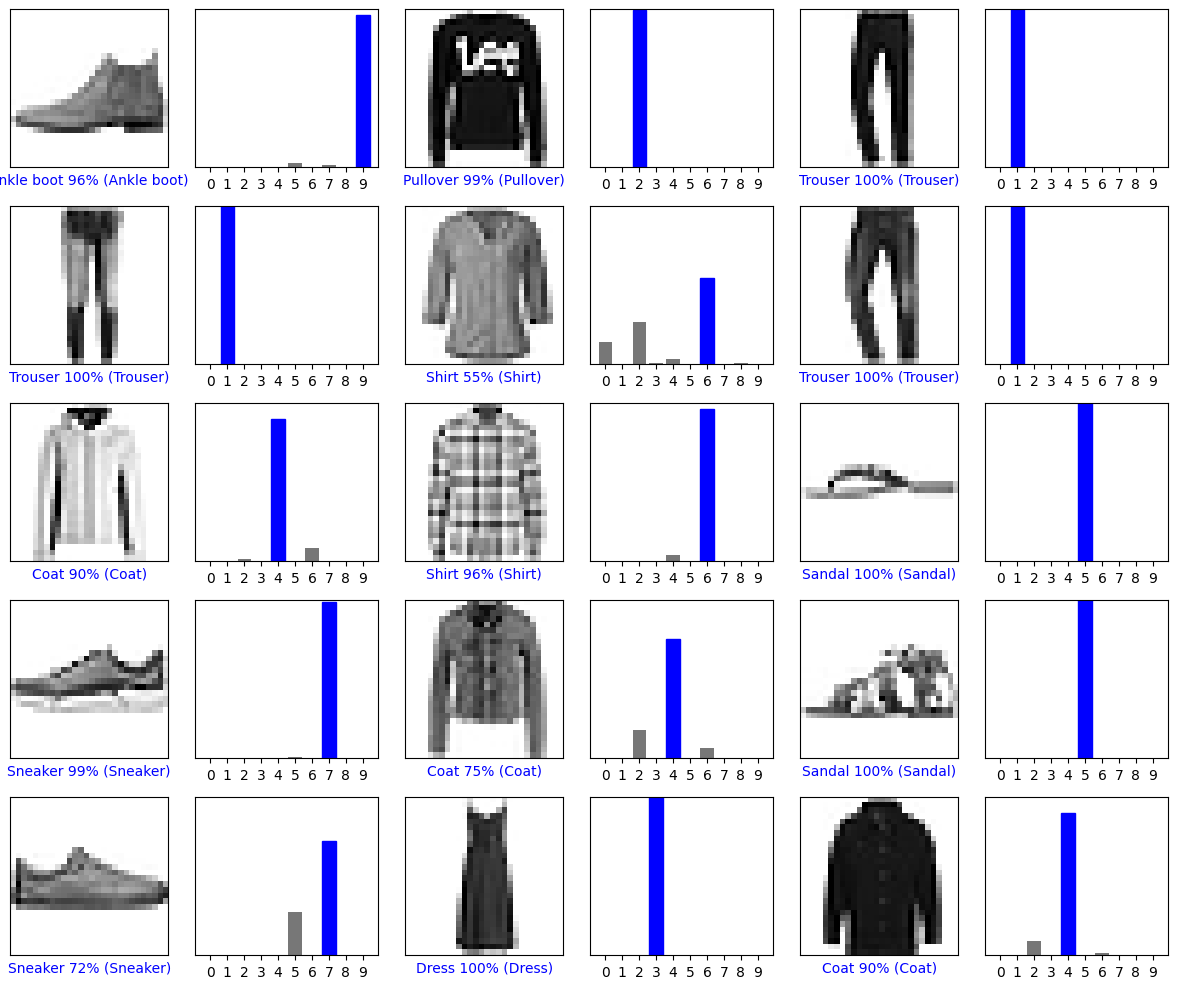

In [67]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
predictions = predictions.numpy()
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

### Single Image Prediction

In [68]:
# Grab an image from the test dataset.
img = test_images[1]

print(img.shape)

(28, 28)


In [69]:
# Add the image to a batch where it's the only member.
img = img.reshape(1,*img.shape)

print(img.shape)

(1, 28, 28)


Run the model on this single image:

In [70]:
with torch.no_grad():
  predictions_single = torch.exp(model(torch.tensor(img, dtype=torch.float32)))
print(predictions_single)

tensor([[4.2010e-04, 1.9888e-14, 9.9299e-01, 2.4149e-05, 1.8101e-03, 2.3213e-15,
         4.7555e-03, 5.1211e-21, 1.4510e-06, 5.3717e-13]])


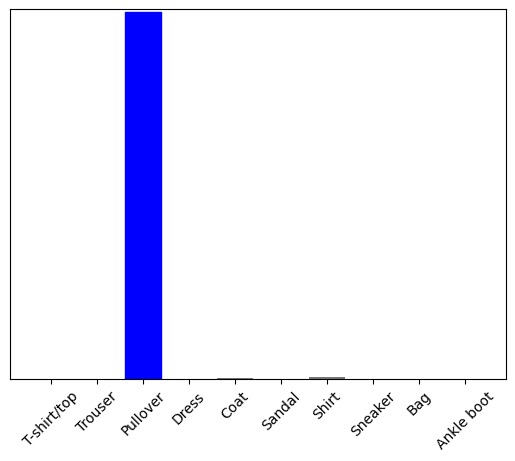

In [71]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)

In [72]:
np.argmax(predictions_single[0])

tensor(2)

Y el modelo predice una etiqueta de 2.

## Reflection Questions

1. **Spatial information loss.** Flattening a 28×28 image to 784 features destroys the 2D spatial structure. Concretely, what spatial property does the MLP lose that makes CNNs better for images?

2. **Softmax and cross-entropy.** Prove that minimising the cross-entropy loss $-\log \hat{p}_y$ is equivalent to maximising the log-likelihood under a categorical distribution. Why is this the correct loss for multiclass classification?

3. **Overfitting.** The test accuracy is lower than train accuracy. List three techniques (besides those used here) that could reduce this gap.

4. **Batch size effect.** What happens to the training curve if you increase the batch size from 64 to 1024? What about memory usage?

## Answers

**1. Spatial information loss.**
The MLP treats pixels at positions $(0,0)$ and $(27,27)$ as completely independent features — there is no notion of "these two pixels are adjacent". Spatial properties like translation, local edges, and textures are encoded in *relative positions* of pixels. CNNs use local filters that explicitly exploit this structure.

**2. Softmax and cross-entropy.**
The categorical distribution has likelihood $P(y=k) = p_k$. For a dataset of $m$ i.i.d. examples, the log-likelihood is $\sum_i \log \hat{p}_{y_i}$. Maximising this is equivalent to minimising $-\frac{1}{m}\sum_i \log \hat{p}_{y_i}$, which is exactly the cross-entropy loss.

**3. Reducing overfitting.**
- L2 weight regularisation (weight decay)
- Dropout layers
- Data augmentation
- Early stopping
- Collecting more training data

**4. Batch size.**
Larger batches give less noisy gradient estimates → smoother loss curve but potentially worse generalisation (sharp minima). Memory usage scales linearly with batch size. Very large batches may require reducing the learning rate proportionally.